<a href="https://colab.research.google.com/github/Guzman2304/Ciencia-de-Datos/blob/main/Avanzado_Cuaderno_19A_GAN_Entrenamiento_FIFA_en_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue"> Taller de Redes Generativas Adversarias Convolucionales Profundas (DCGAN) </font>

<font color="red"> Configure el Google colab con GPU </font>

## Objetivo

En este taller aprenderás a construir una **Red Generativa Adversaria** (GAN), un tipo de red neuronal capaz de **crear imágenes desde cero**. Nos enfocaremos en una variante muy poderosa conocida como **DCGAN** (Deep Convolutional GAN), que utiliza redes convolucionales profundas tanto en el generador como en el discriminador.

> Este taller está diseñado para estudiantes que **nunca han trabajado con GANs**, así que partiremos desde los conceptos básicos y avanzaremos poco a poco, explicando cada parte del código.

---

## GAN

Como vimos en el taller anerior una **GAN (Generative Adversarial Network)** es un modelo compuesto por dos redes neuronales que compiten entre sí:

- **Generador (G):** Intenta crear imágenes falsas que parezcan reales.
- **Discriminador (D):** Intenta distinguir entre imágenes reales y falsas.

Este proceso de competencia ayuda a que el generador aprenda a crear imágenes cada vez más realistas.

---

## DCGAN

Una **DCGAN** es una GAN que usa **capas convolucionales** en ambas redes, aprovechando el poder de las redes que normalmente usamos para clasificación de imágenes (como CNNs), pero ahora para **crear imágenes**.

---

## Taller Fifa:

1. Definiremos el generador y el discriminador usando Keras.
2. Entrenaremos la red usando un conjunto de imágenes reales (Fifa).
3. Visualizaremos cómo las imágenes generadas mejoran con el tiempo.
4. Aprenderás a ajustar los parámetros para mejorar los resultados.


#Descarga y extracción de datos, carga de librerías

## 1. Descarga y preparación de los datos

Antes de entrenar nuestra DCGAN, necesitamos un conjunto de imágenes reales. En este caso, utilizaremos un conjunto de **imágenes de futbolistas del videojuego FIFA**, que hemos preparado previamente y almacenado en un archivo `.zip`.

### ¿Qué hace este bloque de código?

1. Descarga el archivo `fifa.zip` desde Google Drive usando `gdown`.
2. Extrae el contenido automáticamente con `unzip`.
3. Importa las librerías necesarias para el procesamiento de datos:
   - `os`: para manejar archivos y rutas.
   - `tensorflow`: para construir y entrenar la red neuronal.
   - `pandas`: (aún no usado, pero útil si hay metadatos).
   - `matplotlib.pyplot`: para visualizar imágenes generadas.
   - `numpy`: para trabajar con datos numéricos.

> Asegúrate de que el archivo `fifa.zip` contiene un conjunto de imágenes organizadas adecuadamente (por ejemplo, en una carpeta como `fifa_faces/`) para facilitar su lectura posterior.

Dado que este dataset es externo **<font color="red">hay una gran cantidad de archivos sin imagenes o dañados </font>**, vamos a listarlos, pero esto no es un problema para avanzar en el ejercicio dado que hay suficientes imagenes para entrenar el modelo.


In [3]:
# 1. Descarga y extracción de datos
!gdown https://drive.google.com/uc?id=1zpT6gHzvbr21_Vq4NjpRY0JGSaQOSANa
!unzip -q fifa.zip

import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Downloading...
From (original): https://drive.google.com/uc?id=1zpT6gHzvbr21_Vq4NjpRY0JGSaQOSANa
From (redirected): https://drive.google.com/uc?id=1zpT6gHzvbr21_Vq4NjpRY0JGSaQOSANa&confirm=t&uuid=ad94130c-95dc-4cd2-aee7-adb6168ac3bc
To: /content/fifa.zip
100% 320M/320M [00:02<00:00, 145MB/s]
replace Images/0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/100.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/1000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10002.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10003.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10004.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Images/10005.png? [y]es, [n]o, [A]ll, [N]one, [r]enam

## 2. Eliminación del fondo (ruido) en imágenes PNG

Algunas imágenes en el conjunto de datos pueden tener un **canal alfa** (transparencia), que se usa para definir el fondo transparente. Sin embargo, este canal puede interferir con el entrenamiento de la red generativa.

### ¿Qué hace esta función `remove_noise`?

Esta función toma una imagen con 4 canales (R, G, B, Alfa) y elimina el fondo usando la información del canal alfa:

1. `image[:, :, 3] > 50`: selecciona los píxeles que no son completamente transparentes (más del 20% de opacidad).
2. `tf.cast(..., tf.uint8)`: convierte esa máscara booleana en enteros (0 o 1).
3. `tf.expand_dims(...)`: añade un canal para poder hacer una multiplicación compatible.
4. `tf.multiply(image, alpha)`: aplica la máscara a todos los canales (R, G, B).
5. `return noise_filtered[:, :, :3]`: devuelve solo los primeros 3 canales (elimina el canal alfa).

> Objetivo: Quitar el fondo transparente y quedarnos con la imagen limpia del futbolista, lista para el entrenamiento.


In [4]:
def remove_noise(image):
    alpha = image[:, :, 3] > 50
    alpha = tf.cast(alpha, tf.uint8)
    alpha = tf.expand_dims(alpha, axis=-1)
    noise_filtered = tf.multiply(image, alpha)
    return noise_filtered[:, :, :3]

## 3. Lectura y preprocesamiento de imágenes

Para entrenar la DCGAN, necesitamos cargar todas las imágenes desde la carpeta extraída del `.zip`. Esta función hace justamente eso.

### ¿Qué hace `read_voc_images`?

Esta función lee las imágenes desde una carpeta, les quita el fondo (si tienen transparencia), y devuelve dos listas:

- `features`: las imágenes ya procesadas (listas para la red).
- `labels`: identificadores enteros únicos para cada imagen.

### Paso a paso:

1. **Listar archivos**:
   ```python
   files = [os.path.join(voc_dir, file) for file in os.listdir(voc_dir)]
   ```
Ordenarlos numéricamente:

sorted(..., key=lambda i: int(...))


Esto garantiza que las imágenes estén ordenadas por nombre, asumiendo que sus nombres son números (0001.png, 0002.png, etc.).

2. **Leer y procesar imágenes:**

Se leen como imágenes con 4 canales (incluyendo transparencia).

Se limpia el fondo con remove_noise.

Se almacenan en features.

3. **Asignar etiquetas:**

Cada imagen recibe un label_id, simplemente usando su nombre de archivo convertido a entero.

4. **Soporte para carga parcial:**

Si se pasa un número n, solo se cargarán las primeras n imágenes.


Este paso es fundamental para preparar un conjunto limpio de imágenes que alimentará al generador durante el entrenamiento.


In [5]:
def read_voc_images(voc_dir, n=-1):
    files = [os.path.join(voc_dir, file) for file in os.listdir(voc_dir)]
    files = sorted(files, key=lambda i: int(os.path.splitext(os.path.basename(i))[0]))

    features, labels = [], []
    for i, fname in enumerate(files):
        if n != -1 and i == n:
            break
        try:
            raw = tf.io.read_file(fname)
            img = tf.io.decode_image(raw, channels=4, expand_animations=False)
            img = remove_noise(img)
        except Exception as e:
            continue
        features.append(img)
        label_id = int(os.path.splitext(os.path.basename(fname))[0])
        labels.append(label_id)
    return features, labels

## 4. Carga de metadatos y sincronización con imágenes

Para complementar las imágenes, tenemos un archivo `data.csv` que contiene metadatos relacionados con cada futbolista (por ejemplo, su nombre).

### Objetivo

Primero, se carga el archivo CSV con los metadatos usando:

```python
data = pd.read_csv("data.csv")
```

Este archivo puede contener información como nombres, posiciones o equipos.

Luego, se cargan las imágenes y sus etiquetas numéricas asociadas con la función read_voc_images:


```python
caracteristicas, l = read_voc_images("/content/Images")
```


In [6]:
# Carga csv con metadata
data = pd.read_csv("data.csv")
caracteristicas, l = read_voc_images("/content/Images")

datos = data.loc[l]
nombres = list(datos["Name"])


### Visualización de imágenes

Se muestra una cuadrícula con las primeras imágenes y sus nombres asociados. Esto ayuda a verificar que el preprocesamiento fue exitoso.

## Función para mostrar imágenes con títulos

Esta función `mostrar_imagenes` nos ayuda a visualizar un conjunto de imágenes de forma ordenada en una cuadrícula, mostrando opcionalmente un título para cada una.

### ¿Qué hace este código?

- **Parámetros de entrada:**
  - `imagenes`: lista o arreglo de imágenes que queremos mostrar.
  - `num_filas`, `num_columnas`: definen la cuadrícula en la que se mostrarán las imágenes.
  - `titulos`: opcional, una lista con los nombres o etiquetas que aparecerán sobre cada imagen.
  - `escala`: factor para ajustar el tamaño total de la figura.

- **Proceso:**
  - Crea una figura con subplots según filas y columnas indicadas.
  - Convierte las imágenes que están en formato tensor de TensorFlow a numpy para poder mostrarlas con `matplotlib`.
  - Ajusta la forma de la imagen para asegurarse que tenga un formato válido para `imshow`.
  - Muestra cada imagen en su posición correspondiente y oculta los ejes para mejor visualización.
  - Si se proveen títulos, los pone sobre cada imagen.
  - Finalmente, organiza el diseño y muestra la figura.

### ¿Cuál es el objetivo en un proyecto GAN?

- Visualizar las imágenes generadas por el **Generador** en cada etapa del entrenamiento, para ver cómo mejora la calidad.
- Comparar imágenes reales con las generadas, y ayudar a entender si la red está aprendiendo a crear datos realistas.
- Facilitar la interpretación y análisis de resultados de forma visual, que es crucial para ajustar parámetros y detectar problemas.

---

💡 **Aspectos importantes:**

- La función maneja imágenes tanto en formato TensorFlow como en numpy, lo que la hace flexible para usarse dentro del flujo de entrenamiento.
- Visualizar correctamente las imágenes es fundamental para monitorear el progreso de las GANs, ya que la calidad visual es el principal indicador de éxito.
- El uso de títulos ayuda a identificar qué imagen es cuál, muy útil cuando trabajamos con conjuntos con etiquetas o nombres, como en nuestro caso con futbolistas.

---

### Ejemplo de uso:

```python
mostrar_imagenes(caracteristicas[:10], 2, 5, titulos=nombres[:10], escala=2)


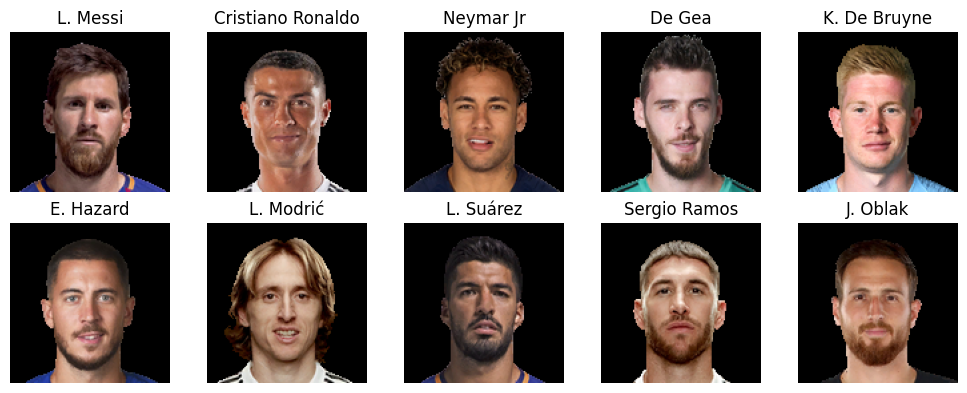

In [7]:
def mostrar_imagenes(imagenes, num_filas, num_columnas, titulos=None, escala=1.5):
    tamaño_figura = (num_columnas * escala, num_filas * escala)
    fig, ejes = plt.subplots(num_filas, num_columnas, figsize=tamaño_figura)
    ejes = ejes.flatten()

    for i, ax in enumerate(ejes):
        if i >= len(imagenes):
            ax.axis('off')
            continue

        img = imagenes[i]
        if tf.is_tensor(img):
            img = img.numpy()

        if img.ndim == 3 and img.shape[-1] == 1:
            img = img.squeeze(-1)
        elif img.ndim == 2:
            pass
        elif img.ndim != 3:
            raise ValueError(f"Formato de imagen no válido: forma {img.shape}")

        ax.imshow(img.astype(np.uint8))
        ax.axis('off')
        if titulos and i < len(titulos):
            ax.set_title(titulos[i])

    plt.tight_layout()
    plt.show()

mostrar_imagenes(caracteristicas[:10], 2, 5, titulos=nombres[:10], escala=2)


### Creación del Dataset de TensorFlow

Transforma las imágenes y etiquetas en un objeto `tf.data.Dataset`, aplicando resizing y normalización. Se usa batching y prefetching para optimizar el rendimiento.


La función `crear_dataset_tf` prepara las imágenes, etiquetas y nombres para ser usados eficientemente en el entrenamiento de nuestro modelo GAN, aprovechando las herramientas que ofrece TensorFlow para manejo de datos.

### ¿Qué hace esta función?

1. **Redimensiona las imágenes** a un tamaño fijo (64x64 píxeles) y convierte sus valores a tipo `float32` para que sean compatibles con la red neuronal.  
   Esto es importante porque las GANs necesitan imágenes de tamaño uniforme.

2. **Convierte las etiquetas y nombres a tensores de TensorFlow**, para que puedan ser manejados dentro del pipeline de entrenamiento sin problemas.

3. **Crea un `tf.data.Dataset`** combinando imágenes, etiquetas y nombres en un solo conjunto de datos. Esto facilita iterar sobre los datos de forma eficiente.

4. Si `barajar=True`, **mezcla aleatoriamente el dataset** para que el modelo no vea siempre las imágenes en el mismo orden, lo que mejora el aprendizaje.

5. **Agrupa los datos en batches (lotes)** del tamaño especificado (por defecto 64). Esto permite procesar múltiples imágenes en paralelo durante cada paso de entrenamiento.

6. **Prefetching:** prepara batches futuros mientras el modelo está entrenando en los actuales, optimizando el rendimiento y reduciendo tiempos de espera.

### ¿Por qué es importante para un proyecto GAN?

- **Eficiencia:** Entrenar con batches y prefetching acelera el proceso y permite usar la GPU de forma óptima.
- **Consistencia:** Asegura que todas las imágenes tengan el tamaño correcto y estén en el formato esperado.
- **Control:** Facilita el manejo simultáneo de imágenes, etiquetas y metadatos (como nombres), para análisis o visualizaciones posteriores.
- **Generalización:** Barajar los datos evita que el modelo se "memorice" el orden y promueve un aprendizaje más robusto.

---


In [ ]:
def crear_dataset_tf(imagenes, etiquetas, nombres, batch_size=64, barajar=True):
    # Aplicar redimensionamiento, conversión de tipo y normalización en la comprensión de lista
    imagenes = [
        (tf.image.resize(tf.cast(img, tf.float32), (64, 64)) / 127.5) - 1.0
        for img in imagenes
    ]
    etiquetas = tf.convert_to_tensor(etiquetas, dtype=tf.int32)
    nombres = tf.convert_to_tensor(nombres, dtype=tf.string)

    dataset = tf.data.Dataset.from_tensor_slices((imagenes, etiquetas, nombres))
    if barajar:
        dataset = dataset.shuffle(buffer_size=len(imagenes))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

fifa_dataset = crear_dataset_tf(caracteristicas, l, nombres)

### Arquitecturas de la GAN: Generador y Discriminador

Se definen las redes neuronales para la GAN. El generador crea imágenes sintéticas a partir de ruido y el discriminador evalúa si una imagen es real o generada.

- `G_block`: bloque reutilizable del generador con `Conv2DTranspose`, `BatchNorm` y `ReLU`.
- El discriminador usa `Conv2D`, `LeakyReLU` y `BatchNorm`.

## Construcción del Generador y Discriminador de una DCGAN

En esta sección definimos las dos redes neurales clave de nuestra GAN:

- 🔧 **Generador:** crea imágenes falsas a partir de ruido.
- 🛡 **Discriminador:** trata de distinguir entre imágenes reales y falsas.

---

### ¿Qué es un G_block?

La función `G_block` es un bloque modular que usamos para construir el generador. Cada bloque:
1. **Conv2DTranspose:** genera una imagen de mayor resolución (upsampling).
2. **BatchNormalization:** estabiliza el aprendizaje.
3. **ReLU:** función de activación que ayuda al generador a aprender representaciones no lineales.

Este bloque se repite varias veces para ir construyendo la imagen paso a paso desde una representación muy pequeña (4x4) hasta una de tamaño 64x64.

---

### `construir_generador`

Esta función construye el modelo generador:

```python
def construir_generador(n_G=64, z_dim=100):

```

* z_dim es la dimensión del ruido de entrada (vector aleatorio).

* n_G es el número base de filtros (profundidad).

**Arquitectura:**

Empieza con un vector de ruido (z_dim).

Lo convierte en un tensor de 4x4x512 usando una capa Dense + Reshape.

Usa 3 G_blocks para aumentar progresivamente la resolución:

4x4 → 8x8 → 16x16 → 32x32

Una última Conv2DTranspose crea una imagen de 64x64 con 3 canales (RGB).

La salida pasa por tanh, lo que normaliza los valores a estar entre -1 y 1 (lo que requiere que nuestras imágenes reales también estén normalizadas así).*


In [ ]:
from tensorflow.keras import layers

def G_block(out_channels, kernel_size=4, strides=2, padding='same'):
    block = tf.keras.Sequential([
        layers.Conv2DTranspose(out_channels, kernel_size, strides=strides, padding=padding, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU()
    ])
    return block

def construir_generador(n_G=64, z_dim=100):
    modelo = tf.keras.Sequential([
        layers.Input(shape=(z_dim,)),
        layers.Dense(4*4*n_G*8, use_bias=False),
        layers.Reshape((4, 4, n_G*8)),

        G_block(n_G*4),  # 8x8
        G_block(n_G*2),  # 16x16
        G_block(n_G),    # 32x32

        layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding='same', use_bias=False),
        layers.Activation('tanh')  # Salida en [-1, 1]
    ])
    return modelo

def construir_discriminador(n_D=64):
    modelo = tf.keras.Sequential([
        layers.Input(shape=(64, 64, 3)),

        layers.Conv2D(n_D, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),

        layers.Conv2D(n_D*2, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2D(n_D*4, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2D(n_D*8, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return modelo

generador = construir_generador()
discriminador = construir_discriminador()


### ⚙️ Funciones de pérdida y optimización

Se definen las funciones de pérdida para el generador y el discriminador usando `BinaryCrossentropy`. También se instancian los optimizadores `Adam` con parámetros específicos para estabilidad.

## Funciones de pérdida y optimizadores en una DCGAN

En este bloque definimos las funciones de pérdida y los algoritmos de optimización que usaremos para entrenar tanto al **generador** como al **discriminador**.



###  ¿Qué es una función de pérdida?

La función de pérdida nos dice **qué tan mal lo está haciendo un modelo**. En el caso de una GAN, necesitamos dos funciones diferentes:

- Una para el **discriminador**: aprender a distinguir entre imágenes reales y falsas.
- Otra para el **generador**: aprender a engañar al discriminador.



### Binary Cross-Entropy

```python
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


### loss_discriminador

* El discriminador debe asignar 1 a las imágenes reales (real_logits) y 0 a las falsas (fake_logits).

* Calculamos la pérdida por separado para reales y falsas y las sumamos.

* El objetivo del discriminador es minimizar esta pérdida, mejorando su capacidad de distinguir.

### loss_generador

El generador quiere que el discriminador crea que las imágenes falsas son reales.

Por eso, la función de pérdida del generador compara las salidas del discriminador con un vector de unos (como si fueran reales).


### Optimizadores

Usamos el optimizador Adam, que es ideal para redes profundas.

La tasa de aprendizaje 1e-4 (0.0001) es típica para GANs.

El parámetro beta_1=0.5 es recomendado en el paper original de DCGAN, ya que ayuda a estabilizar el entrenamiento.

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def loss_discriminador(real_logits, fake_logits):
    real_loss = cross_entropy(tf.ones_like(real_logits), real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

def loss_generador(fake_logits):
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)

gen_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

### Entrenamiento de la GAN

Entrena la GAN por un número de épocas. Cada batch se utiliza para actualizar los pesos del generador y el discriminador. Además:
- Cada 5 épocas se muestran las mismas imágenes generadas para evaluar progreso visual.
- Al final del entrenamiento, se guardan los modelos `generador_fifa.keras` y `discriminador_fifa.keras`.

### Función de entrenamiento para un batch

Esta función entrena una tanda de imágenes reales, actualizando tanto el generador como el discriminador.


In [ ]:
z_dim = 100  # Dimensión del vector latente

def mostrar_imagenes(generator, num_images=16, z_dim=z_dim, figsize=(4,4)):
    ruido = tf.random.normal([num_images, z_dim])
    imgs = generator(ruido, training=False)
    imgs = (imgs + 1.0) / 2.0

    filas = int(num_images**0.5)
    columnas = filas

    fig, axs = plt.subplots(filas, columnas, figsize=figsize)
    axs = axs.flatten()

    for i, img in enumerate(imgs):
        axs[i].imshow(img)
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

ruido_fijo = tf.random.normal([16, z_dim])

def mostrar_imagenes_fijas(generator, ruido):
    imgs = generator(ruido, training=False)
    imgs = (imgs + 1.0) / 2.0

    plt.figure(figsize=(4,4))
    for i in range(len(ruido)):
        plt.subplot(4, 4, i+1)
        plt.imshow(imgs[i])
        plt.axis('off')
    plt.show()


In [ ]:

def train_step(imagenes_reales):
    batch_size = tf.shape(imagenes_reales)[0]
    ruido = tf.random.normal([batch_size, z_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        imgs_falsas = generador(ruido, training=True)

        logits_reales = discriminador(imagenes_reales, training=True)
        logits_falsas = discriminador(imgs_falsas, training=True)

        loss_D = loss_discriminador(logits_reales, logits_falsas)
        loss_G = loss_generador(logits_falsas)

    grad_G = gen_tape.gradient(loss_G, generador.trainable_variables)
    grad_D = disc_tape.gradient(loss_D, discriminador.trainable_variables)

    gen_optimizer.apply_gradients(zip(grad_G, generador.trainable_variables))
    disc_optimizer.apply_gradients(zip(grad_D, discriminador.trainable_variables))

    return loss_G, loss_D


### Función de entrenamiento completo

Itera sobre las épocas y batches, mostrando el progreso y generando imágenes cada cierto tiempo.


In [ ]:
# Crear modelos
generador = construir_generador()
discriminador = construir_discriminador()

# Forzar construcción para crear variables antes de entrenamiento
generador(tf.random.normal([1, z_dim]))
discriminador(tf.random.normal([1, 64, 64, 3]))

@tf.function
def train_step(imagenes_reales):
    batch_size = tf.shape(imagenes_reales)[0]
    ruido = tf.random.normal([batch_size, z_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        imgs_falsas = generador(ruido, training=True)

        logits_reales = discriminador(imagenes_reales, training=True)
        logits_falsas = discriminador(imgs_falsas, training=True)

        loss_D = loss_discriminador(logits_reales, logits_falsas)
        loss_G = loss_generador(logits_falsas)

    grad_G = gen_tape.gradient(loss_G, generador.trainable_variables)
    grad_D = disc_tape.gradient(loss_D, discriminador.trainable_variables)

    gen_optimizer.apply_gradients(zip(grad_G, generador.trainable_variables))
    disc_optimizer.apply_gradients(zip(grad_D, discriminador.trainable_variables))

    return loss_G, loss_D

In [ ]:
def entrenar(dataset, epochs):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        for batch in dataset:
            loss_G, loss_D = train_step(batch)
        print(f"Gen loss: {loss_G.numpy():.4f}, Disc loss: {loss_D.numpy():.4f}")

        if (epoch + 1) % 5 == 0:
            mostrar_imagenes_fijas(generador, ruido_fijo)

In [ ]:
batch_size = 64
dataset_solo_imgs = fifa_dataset.map(lambda img, etiq, nom: img)
dataset_solo_imgs = dataset_solo_imgs.prefetch(tf.data.AUTOTUNE)



epochs = 100
entrenar(dataset_solo_imgs, epochs)

### Visualización de resultados generados

Se define `mostrar_imagenes_fijas`, que permite observar cómo evolucionan las imágenes generadas a lo largo del entrenamiento, utilizando el mismo vector de ruido.

In [ ]:
ruido = tf.random.normal([1, 100])
imagen_generada = generador(ruido, training=False)[0].numpy()
fig = plt.figure(figsize=(3, 3))
plt.imshow((imagen_generada + 1) / 2)
plt.axis('off')
plt.show()

### Guardar los modelos entrenados

Al final del entrenamiento, guardamos tanto el generador como el discriminador en formato TensorFlow para poder cargar y reutilizar.


In [ ]:
generador.save("generador_fifa_modelo.keras")
discriminador.save("discriminador_fifa_modelo.keras")
